# LibTorch 部署全流程完整教程（使用者指南）

LibTorch 是 PyTorch 官方的 C++ 推理库。  
**目标：在纯 C++ 环境中运行训练好的 PyTorch 模型，完全脱离 Python。**

---

## 一、整体流程

```
Python 端：
  ① 训练模型（得到 .pth 权重）
  ② 导出 TorchScript（得到 .pt 文件）

C++ 端：
  ③ 下载并配置 LibTorch 环境
  ④ 加载 .pt 文件
  ⑤ 准备输入数据
  ⑥ 执行推理
  ⑦ 处理输出结果
```

---

## 二、Python 导出 TorchScript

### 2.1 为什么不能直接用 .pth 文件？
`.pth` 只存储权重，不包含模型结构（`forward` 逻辑）。  
C++ 必须拿到**完整计算图**，因此需要先转为 TorchScript。

### 2.2 两种导出方式

| 方式 | 适用场景 | 优点 | 缺点 |
|------|----------|------|------|
| `torch.jit.trace` | 无 if/while 的纯计算图 | 简单，图优化充分 | 丢失控制流，动态尺寸可能出错 |
| `torch.jit.script` | 有控制流、动态逻辑 | 完整保留控制流 | 语法限制较多，部分 Python 语法不支持 |

**工业界原则：优先尝试 script，失败再改用 trace。**

### 2.3 trace 导出（常用示例）
```python
model = MyModel()
model.load_state_dict(torch.load("weights.pth"))
model.eval()                         # 必须！否则 BN/Dropout 行为异常

example = torch.randn(1, 3, 224, 224)
traced = torch.jit.trace(model, example)
traced.save("model_trace.pt")
```

### 2.4 script 导出
```python
scripted = torch.jit.script(model)
scripted.save("model_script.pt")
```

### 2.5 导出后验证（关键）
```python
loaded = torch.jit.load("model.pt")
with torch.no_grad():
    out_orig = model(example)
    out_jit  = loaded(example)
print(torch.allclose(out_orig, out_jit))   # 应为 True
```

---

## 三、C++ 开发环境配置（LibTorch）

### 3.1 下载 LibTorch
- 访问 [pytorch.org](https://pytorch.org) → **LibTorch** 页面
- 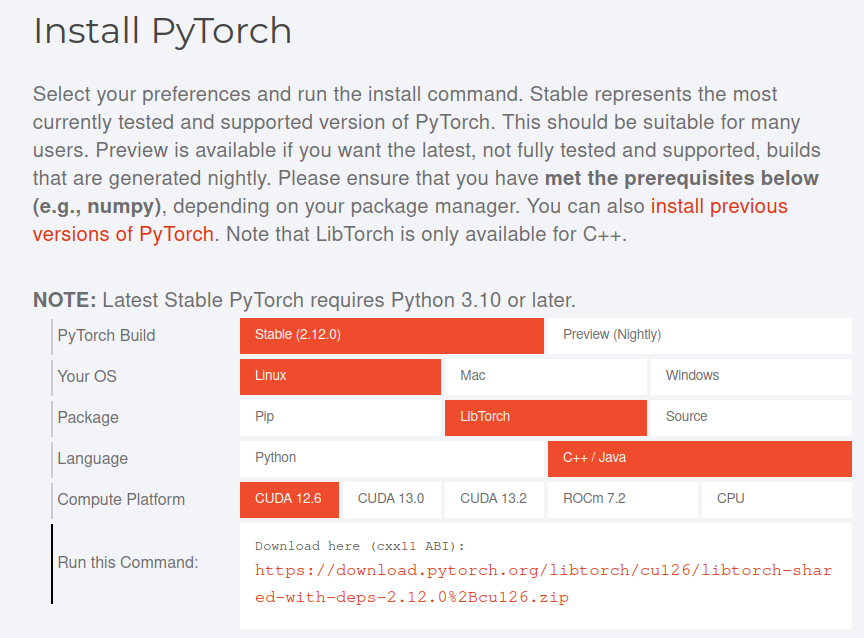
- 选择操作系统、CUDA 版本（或 CPU-only）、Release 版本
- 下载并解压，得到类似目录结构：

比如cuda 12.1版本的：  
cuda12.1 (Release version):	https://download.pytorch.org/libtorch/cu121/libtorch-win-shared-with-deps-2.5.0%2Bcu121.zip

还有CPU版本的:  https://download.pytorch.org/libtorch/cpu/libtorch-shared-with-deps-2.12.0%2Bcpu.zip

实际上，GPU版本压缩包有大概2.2GB,CPU版本有200MB，编译所需的环境还是挺大的，不过最终C++版本生成可执行文件,还是比较小的

```
libtorch/
├── include/          # 头文件
├── lib/              # 动态库 (.so / .dylib / .lib)
└── share/            # CMake 配置
```

**注意**：LibTorch 版本必须与导出模型的 PyTorch **主版本一致**（例如都用 2.0.x）。

### 3.2 编写 CMakeLists.txt

```cmake
cmake_minimum_required(VERSION 3.18 FATAL_ERROR)
project(DeployApp LANGUAGES CXX)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_CXX_STANDARD_REQUIRED ON)

# 指定 LibTorch 路径（解压后目录）
set(TORCH_ROOT ${CMAKE_CURRENT_SOURCE_DIR}/libtorch)
find_package(Torch REQUIRED PATHS ${TORCH_ROOT})

add_executable(main main.cpp)
target_link_libraries(main "${TORCH_LIBRARIES}")

# 确保运行时能找到动态库（Linux/macOS）
set_target_properties(main PROPERTIES
    BUILD_RPATH "${TORCH_ROOT}/lib"
    INSTALL_RPATH "${TORCH_ROOT}/lib"
)
```

**Windows 特别提醒**：运行时需要将 `libtorch/lib` 下的所有 `.dll` 文件拷贝到 `.exe` 同级目录，或添加到 PATH。

### 3.3 编译
```bash
mkdir build && cd build
cmake -DCMAKE_PREFIX_PATH=/path/to/libtorch ..
make -j$(nproc)
```

---

## 四、C++ 推理核心 API

### 4.1 加载模型
```cpp
#include <torch/script.h>

torch::jit::script::Module model;
try {
    model = torch::jit::load("model.pt");               // CPU 加载
    // model = torch::jit::load("model.pt", torch::kCUDA); // 直接加载到 GPU
} catch (const c10::Error& e) {
    std::cerr << "加载失败: " << e.what() << std::endl;
    return -1;
}
```

### 4.2 设备管理
```cpp
// 移至 CPU（默认）
model.to(torch::kCPU);

// 移至 GPU（需检查可用性）
if (torch::cuda::is_available()) {
    model.to(torch::kCUDA, 0);   // 第 0 块 GPU
}
```

### 4.3 创建输入张量
#### ① 随机/常量张量
```cpp
auto x = torch::rand({1, 3, 224, 224});       // 随机
auto y = torch::zeros({1, 10});               // 全 0
auto z = torch::ones({1, 3, 224, 224});       // 全 1
auto w = torch::full({1, 5}, 0.5f);           // 填充标量
```

#### ② 从外部数据指针创建（常用）
```cpp
float* data = /* 来自图片读取的 float 数组 */;
auto input = torch::from_blob(data, {1, 3, 224, 224});
// 若需控制数据类型和设备，可加选项
auto options = torch::TensorOptions().dtype(torch::kFloat32).device(torch::kCUDA, 0);
auto input = torch::from_blob(data, {1, 3, 224, 224}, options);
```

#### ③ 指定数据类型和设备创建
```cpp
auto options = torch::TensorOptions()
                  .dtype(torch::kFloat32)
                  .device(torch::kCUDA, 0);
auto t = torch::zeros({1, 10}, options);
```

#### ④ 类型转换
```cpp
auto fp32_tensor = torch::rand({1, 10});
auto int_tensor  = fp32_tensor.to(torch::kInt32);
```

### 4.4 关闭梯度（必须）
```cpp
c10::InferenceMode guard;   // 比 torch::NoGradGuard 更彻底，性能更好
```

### 4.5 执行推理
```cpp
std::vector<torch::jit::IValue> inputs;
inputs.push_back(input_tensor);

auto output = model.forward(inputs);   // 返回 torch::jit::IValue

// 若模型有多个输入，按顺序 push_back
```

### 4.6 处理输出
```cpp
// 单个输出（最常见）
if (output.isTensor()) {
    torch::Tensor result = output.toTensor();
    std::cout << "Shape: " << result.sizes() << std::endl;
}

// 多个输出（模型返回 tuple 时）
if (output.isTuple()) {
    auto tuple = output.toTuple();
    auto out1 = tuple->elements()[0].toTensor();
    auto out2 = tuple->elements()[1].toTensor();
}
```

### 4.7 常用后处理 API
```cpp
auto logits = output.toTensor();
auto probs = torch::softmax(logits, 1);        // 概率化

auto max_idx = probs.argmax(1);                // 最大索引
auto top5 = probs.topk(5);                     // TopK
auto top_values  = std::get<0>(top5);          // 值
auto top_indices = std::get<1>(top5);          // 索引
```

### 4.8 张量维度操作
```cpp
auto x = torch::rand({4, 3, 224, 224});
auto y = x.view({4, -1});                     // 变形，-1 自动推导
auto z = x.permute({0, 2, 3, 1});             // 维度置换
auto b = x.slice(/*dim=*/1, /*start=*/0, /*end=*/1);  // 切片
auto c = x.index_select(1, torch::tensor({0, 2}));    // 按索引选取
```

### 4.9 多方法模型
```cpp
// 如果模型导出了多个方法，比如 "encode"
auto encode = model.get_method("encode");
auto output = encode({input});
```

### 4.10 保存/加载张量
```cpp
torch::save(tensor, "tensor.pt");
auto loaded = torch::load("tensor.pt");
```

---

## 五、生产环境优化

### 5.1 设置 CPU 线程数
```cpp
at::set_num_threads(4);   // 控制算子内部并行度
```

### 5.2 GPU 同步计时
```cpp
if (torch::cuda::is_available()) {
    torch::cuda::synchronize();   // 等待所有 CUDA 操作完成
}
```

### 5.3 多线程安全（模型克隆）
```cpp
// Module 不是线程安全的，每个线程需持有自己的副本
auto thread_model = model.clone();
```

### 5.4 释放 GPU 显存碎片
```cpp
torch::cuda::empty_cache();
```

### 5.5 设置随机种子（调试用）
```cpp
torch::manual_seed(42);
```

---

## 六、完整最小可运行示例

```cpp
#include <torch/script.h>
#include <iostream>

int main() {
    // 1. 加载模型
    auto model = torch::jit::load("model.pt");
    model.to(torch::kCPU);

    // 2. 准备输入（从外部数据）
    // 假设已有 float* image_data，shape 为 {1, 3, 224, 224}
    auto input = torch::from_blob(image_data, {1, 3, 224, 224});

    // 3. 推理
    c10::InferenceMode guard;
    auto output = model.forward({input});

    // 4. 处理结果
    if (output.isTensor()) {
        auto result = output.toTensor();
        auto prob = torch::softmax(result, 1);
        auto class_id = prob.argmax(1);
        std::cout << "Predicted class: " << class_id.item<int>() << std::endl;
    }

    return 0;
}
```

---

## 七、常见问题速查

| 现象 | 原因 | 解决 |
|------|------|------|
| 加载报 `version_number` | LibTorch 与 PyTorch 版本不匹配 | 下载与训练环境主版本一致的 LibTorch |
| `Expected all tensors to be on the same device` | 模型与输入不在同一设备 | 统一使用 `.to()` 移至相同设备 |
| 小 batch 推理结果异常 | 导出前未设置 `model.eval()` | 导出前执行 `model.eval()` |
| 修改 batch size 后出错 | trace 固定了维度，导致动态尺寸失效 | 改用 script 导出，或 trace 后手动修正尺寸 |
| 运行时找不到 `libtorch_cpu.so` | 动态库路径未配置 | 设置 `LD_LIBRARY_PATH` 或编译时指定 RPATH |
| 内存/显存持续增长 | 中间张量未释放 | 推理后使用 `tensor.reset()` 或让其自然离开作用域 |

---

## 八、总结

掌握以下最常用的 API 即可应对 90% 的部署场景：

```
load → to(device) → from_blob / rand → forward → toTensor / softmax / argmax
```

其余 API 按需查阅 [LibTorch 官方文档](https://pytorch.org/cppdocs/) 即可。  
本教程覆盖了**环境搭建、模型导出、核心推理、常用后处理及生产优化**的全部内容，可直接用于实际项目。